# Reinforcement Learning assignment

For the full instructions, please see the assignment pdf file!

Please remove any **instructions in italic** from this file before submitting.

In [ ]:
import importlib
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

import dp
import mc
import td
importlib.reload(dp)
importlib.reload(mc)
importlib.reload(td)
from dp import *
from mc import *
from td import *
# Add more imports if needed. Add these into the requirements.txt file.

# Abstract

_insert your abstract here_

# 0. Environment

Declare your environment here. Feel free to use add any code cells.

In [ ]:
# it initializes the environment
env = gym.make('FakeMinecraft-v1') # , render_mode="human" 

def plot_results(V, policy, title):
    # it reshapes the value function to fit the grid
    size = int(np.sqrt(len(V)))
    V_grid = V.reshape((size, size))
    
    fig, ax = plt.subplots(figsize=(8, 8))
    # it creates a heatmap of the values
    im = ax.imshow(V_grid, cmap='viridis')
    plt.colorbar(im, label='Value (V)')
    
    # it adds arrows to represent the actions (0=Right, 1=Up, 2=Left, 3=Down)
    dx = [0.4, 0, -0.4, 0]
    dy = [0, -0.4, 0, 0.4]
    
    for s in range(len(V)):
        y, x = s // size, s % size
        action = np.argmax(policy[s])
        # it only draws arrows for non-zero states to avoid cluttering terminal tiles
        if V[s] != 0:
            ax.arrow(x, y, dx[action], dy[action], head_width=0.1, head_length=0.1, fc='white', ec='white')

    ax.set_title(title)
    plt.show()

In order to see the action that agents takes in each step, please set render_mode to human in the environment declaration.

# 1. Introduction

_insert your introduction in this cell_

_describe your environment and the problem the agent has to solve_

_describe the objective of the report (e.g. comparing various RL algorithms) and how you are going to accomplish this (research question)_

_don't forget to add plots/images of the environment, can be done via code cells, but also by inserting .png files into the jupyter notebook_

Our enviroment is a grid 12x12. There is a starting space on the bottom left corner. When the game is terminated the agent starts on this space. In the eviroment there are some holes which give a negative reward if the agent 'falls' into them. Furthermore, there are some walls on certain tiles which the agent can not move on. There are also some lava tiles, when the agent steps on these the episode is terminated. Lastly there is the diamond tile, this is the goal tile for the agent to reach. If the agent moves outside the grid it is put back on the same tile where it left the grid from. It is the agents goal to move from the start tile to the goal tile while maximizing its reward and avoiding obsticals. The agent will use 3 different type of algorithms to fulfill this objective; Monte Carlo, Dynamic Programming and Temporal diffence. After testing each algorithm, they will be compared to each other to find the optimal algorithm.

# 2. Dynamic Programming algorithms

First run the Dynamic Programming algorithms (Policy Iteration and Value Iteration) by calling functions from the separate `dp.py` file, and create plots. Then, fill in the cell completing your 'report' within this file.

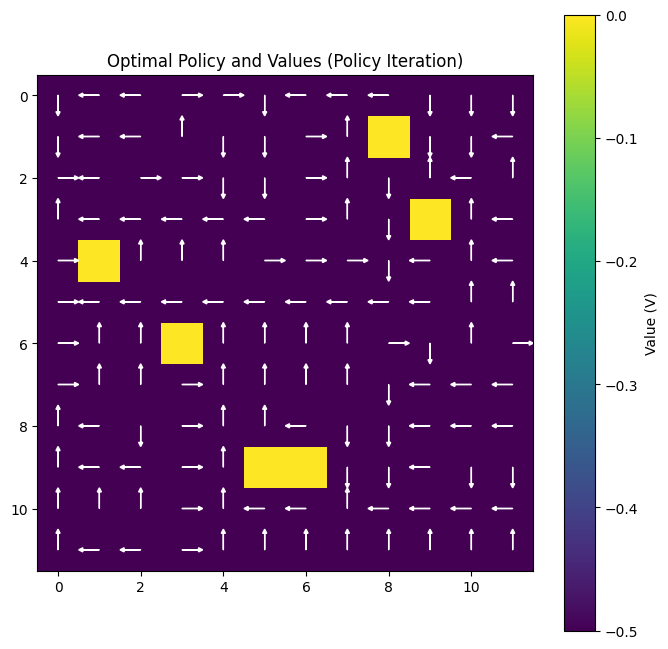

In [13]:
# it runs policy iteration and plots the result
V_pi, policy_pi = policy_iteration(env)
plot_results(V_pi, policy_pi, "Optimal Policy and Values (Policy Iteration)")

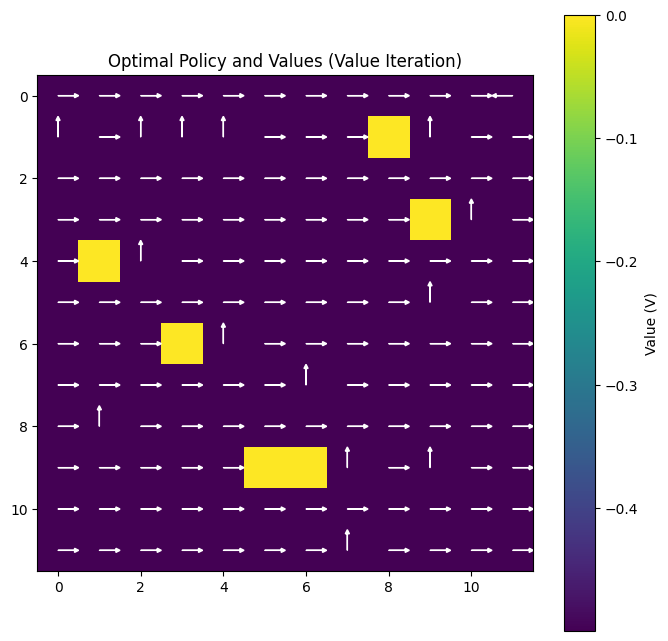

Max difference: 9.134391211307324e-06


In [ ]:
# it runs value iteration and plots the result
V_vi, policy_vi = value_iteration(env)
plot_results(V_vi, policy_vi, "Optimal Policy and Values (Value Iteration)")

For this part of the assignment, We implemented two main planning methods to solve our grid world. Since we have full access to the map layout, we can use Dynamic Programming to calculate the best possible moves before the agent even starts. This is a big advantage because the agent doesn't have to learn by trial and error, it follows the rules and limitations.

Policy Iteration works in a loop where it first evaluates the current policy by figuring out how much total reward we expect from each tile. After that, it updates the policy by picking the best action for every single state. I noticed it only took a few iterations to stabilize, which makes sense for a map this size. Value Iteration is a bit more direct because it just updates the values by picking the maximum possible reward at each step. It's essentially combining the evaluation and improvement into one process. 

When comparing the results, both algorithms produced almost identical value functions. You can see from the heatmap that the values get higher as we get closer to the diamond, which is exactly what we expect. The policy arrows show that the agent is smart enough to take a path that completely avoids the lava tiles while also staying away from the holes to keep the total reward high. This confirms that the principle of optimality works here. Once we have the best values for the next states, the best action for the current state is easy to find.

# 3. Monte Carlo algorithms

First run the Monte Carlo algorithm (Monte Carlo Exploring Starts or Monte Carlo without Exploring Starts (with $\epsilon$-greedy strategy)) by calling functions from the separate `mc.py` file, and create plots. Then, fill in the cell completing your 'report' within this file.

In [ ]:
agent = MonteCarloAgent(env, initial_epsilon=1.0, epsilon_decay=0.9995, final_epsilon=0.05, discount_factor=0.95)
num_episodes = 200

for episode_idx in range(num_episodes):
    state, _ = env.reset()
    done = False
    episode = []
    while not done:
        action = agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)

        episode.append((state, action, reward))
        state = next_state
        done = terminated or truncated

    g = agent.update(episode)
    agent.decay_epsilon()


plot_policy(agent.q_values)

_In this cell, describe how the algorithms work, how the algorithms differ (compared to the one you did not code), plot results and/or policies (add more code cells!), etc._

Monte Carlo algorithms learn by playing full episodes and then updating values at the end based on the total reward collected. So instead of updating after every step, the agent waits until the episode is finished and then uses that experience to improve its estimates of state action pair values and its policy.

One difference in Monte Carlo methods is whether you use Exploring Starts or not. Exploring Starts means every episode begins from a random state action pair, which guarantees that all state action pairs will be visited. This would probably be a better approach, however we decided not to use it for the fun of it.

Since we didn't use exploring starts, in order to handle exploration we used an epsilon - greedy strategy. This strategy differs from greedy in that rather than always picking the best action it has a non-zero chance to pick a random action.

# 4. Temporal Difference algorithms

First run the Temporal Difference algorithms (SARSA and Q-learning) by calling functions from the separate `td.py` file, and create plots. Then, fill in the cell completing your 'report' within this file.

In [ ]:
TDagent = TemporalDifferenceAgent(env, initial_epsilon =0.95, epsilon_decay = 0.9, final_epsilon= 0.01 , gamma =0.8, alpha =0.2)
print_ep_with_diamonds = False # NOTE setting this to TRUE will print out indexes of all episodes in which the agent found the diamond

# Call SARSA algorithm
q_sarsa, ep_id_with_diamonds_sarsa, rewards_per_episode_sarsa = TDagent.sarsa(200)
plot_policy(q_sarsa)

if print_ep_with_diamonds:
    print(ep_id_with_diamonds_sarsa)

[-4.4999999999999964, -2.950000000000001, -4.649999999999997, -3.3999999999999995, -9.599999999999989, -11.300000000000008, -5.349999999999994, -7.199999999999988, -7.849999999999986, 7.150000000000002, -8.699999999999982, -2.4500000000000006, -7.799999999999984, -13.850000000000042, -4.699999999999996, -5.5999999999999925, -2.650000000000001, -14.800000000000054, -14.400000000000048, -1.85, -5.449999999999994, -5.949999999999991, -11.750000000000012, -4.4999999999999964, -12.000000000000021, -6.699999999999989, -4.699999999999996, -10.4, 5.350000000000008, -3.9499999999999975, -8.599999999999982, -3.649999999999999, -14.050000000000189, 5.350000000000008, -13.650000000000034, -12.65000000000018, 4.500000000000011, -5.349999999999993, 3.500000000000014, 4.500000000000011, 4.550000000000009, 6.5000000000000036, -7.149999999999986, -2.4500000000000366, 6.200000000000003, -3.5500000000000504, 1.9000000000000181, -1.0500000000000203, 5.100000000000008, 0.9000000000000075, 3.450000000000014

In [ ]:
# Call Q-learning algorithm
q_qlearn, ep_id_with_diamonds_q, rewards_per_episode_q = TDagent.q_learning(200)
plot_policy(q_qlearn)

if print_ep_with_diamonds:
    print(ep_id_with_diamonds_q)

We found that on average SARSA outperforms Q learning. After 200 episodes SARSA converges to a optimal policy that takes 19 steps to arrive to the diamond, while Q learning is close to converging to a single policy. However, in the first episodes Q learning finds diamonds more often then SARSA. 

# 5. Comparison and discussion

Compare different algorithms (MC and TD with plots). You don’t need to plot DP alongside MC and TD since DP is not a learning algorithm. However, DP can provide the ground truth for optimal state or action values, which can serve as a reference when evaluating MC and TD. You can choose to plot any of the following: cumulative reward, root mean squared error, sample efficiency, or any other metric you think is a fair comparison.

Include a discussion: what can you conclude by comparing different RL algorithms? Do they have certain strengths or limitations?

_Add as many text cells as you like_

In [ ]:
# Add as many code cells as you like

rewards_per_episode_sarsa


# 6. Conclusion

Conclude your project.

_Add as many text cells as you like_